# Module 2c - From a Live Literature Search to a Dataset

Type a topic, pull the open-access papers for it, read their **full text**, and turn them into a clean table you can model. This first part does the harvest: **an OpenAlex filter you build on the website, pasted here, becomes a corpus of full-text PDFs downloaded and parsed automatically.**

**The live-demo flow**
1. On **openalex.org** search a topic and click filters until the page reads something like:
   *works where open access is (true) and year >= (2019) and title/abstract has (battery capacity mAh) and type is (article) and citation count >= (100)*
2. Copy the filter (the site shows the API query), paste it into the config cell below.
3. Run: the notebook pulls that corpus, downloads each open-access full-text PDF, and parses it.

No key and no login for any of this (OpenAlex is free; a courtesy email is optional).

## 0. Setup

In [1]:
import sys, subprocess
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "requests", "pymupdf"])
import requests, re, io, time
print("ready")

ready


## 1. Paste your OpenAlex query (OQL)

Build the query on **openalex.org** by clicking filters. The builder writes it in **OQL** (OpenAlex Query Language), e.g.

```
works where citation count >= (100)
  and open access is (true)
  and year >= (2020)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
```

**Copy that OQL and paste it below** - the notebook translates it into the OpenAlex API query. (It also accepts a full `api.openalex.org/works?...` URL or a raw filter string.)

In [2]:
import re
# Paste the OQL exactly as the openalex.org builder writes it (or a URL / raw filter):
OQL = """
works where citation count >= (100)
  and open access is (true)
  and year >= (2020)
  and title/abstract has (battery capacity and mAh)
  and type is (article)
"""

USE_CACHE = True   # True: read the shipped pre-crawled cache (offline, instant). False: crawl live.
N_PAPERS = 20                       # how many full-text papers to harvest (demo: 15-30)
MAILTO   = "ruiding@uchicago.edu"   # courtesy only, NOT a key; may be ""

# OQL display-name -> OpenAlex API filter key. Names whose key is just the snake_case
# of the name are handled by the fallback below, so any extra field a student adds
# on openalex.org keeps working; only genuinely unknown fields get a warning.
OQL_FIELDS = {
    "citation count": "cited_by_count", "cited by count": "cited_by_count",
    "year": "publication_year", "publication year": "publication_year",
    "open access": "open_access.is_oa", "is open access": "open_access.is_oa",
    "title/abstract": "title_and_abstract.search", "title and abstract": "title_and_abstract.search",
    "title": "title.search", "abstract": "abstract.search", "fulltext": "fulltext.search",
    "type": "type", "language": "language", "publication date": "publication_date",
    "is retracted": "is_retracted", "has doi": "has_doi",
    "has abstract": "has_abstract", "has fulltext": "has_fulltext",
}
SEARCHY = {"title_and_abstract.search", "title.search", "abstract.search", "fulltext.search"}

def parse_oql(text):
    """Translate OpenAlex OQL into an API filter. Also accepts a full openalex.org URL or raw filter."""
    t = text.strip()
    if "openalex.org" in t and "filter=" in t:
        from urllib.parse import urlparse, parse_qs, unquote
        return unquote(parse_qs(urlparse(t).query).get("filter", [""])[0])
    if ("where" not in t.lower()) and re.search(r"[a-z_]+\.[a-z_]+:", t):
        return t
    t = re.sub(r"^\s*works\s+where\s+", "", t, flags=re.I)
    parts, guessed = [], []
    for fld, op, val in re.findall(r"([a-zA-Z /_]+?)\s*(>=|<=|>|<|is not|is|has)\s*\(([^)]*)\)", t):
        fld = re.sub(r"^and\b\s*", "", fld.strip().lower()).strip(); val = val.strip()
        key = OQL_FIELDS.get(fld)
        if not key:                                   # fallback: name -> snake_case key
            key = re.sub(r"[ /]+", "_", fld); guessed.append(f"{fld} -> {key}")
        if key in SEARCHY:
            parts.append(f"{key}:" + re.sub(r"\s+and\s+", " ", val, flags=re.I)); continue
        v = val.lower() if val.lower() in ("true", "false") else val
        neg = "!" if op == "is not" else ""
        if op == ">=":   parts.append(f"{key}:>{int(val)-1}")
        elif op == "<=": parts.append(f"{key}:<{int(val)+1}")
        elif op == ">":  parts.append(f"{key}:>{val}")
        elif op == "<":  parts.append(f"{key}:<{val}")
        else:            parts.append(f"{key}:{neg}{v}")
    if guessed:
        print("  note: guessed these field keys (check OpenAlex docs if a query errors):", guessed)
    return ",".join(parts)

FILTER = parse_oql(OQL)
print("translated OQL -> OpenAlex filter:\n ", FILTER)

translated OQL -> OpenAlex filter:
  cited_by_count:>99,open_access.is_oa:true,publication_year:>2019,title_and_abstract.search:battery capacity mAh,type:article


## 2. Pull the corpus

Ask OpenAlex for works matching the filter, sorted by citations, and keep the ones that actually have a downloadable open-access PDF.

In [3]:
import pandas as pd, gzip, json, os
CACHE = "cache"
def openalex_count(filt, mail=""):
    p={"filter":filt,"per-page":1}
    if mail: p["mailto"]=mail
    return requests.get("https://api.openalex.org/works", params=p, timeout=45).json()["meta"]["count"]
def get_corpus(filt, n, mail=""):
    base,out,cur="https://api.openalex.org/works",[], "*"
    while len(out)<n:
        p={"filter":filt,"sort":"cited_by_count:desc","per-page":min(200,n-len(out)),"cursor":cur}
        if mail: p["mailto"]=mail
        j=requests.get(base,params=p,timeout=60).json(); res=j.get("results",[])
        if not res: break
        for w in res:
            loc=w.get("best_oa_location") or {}
            out.append(dict(title=(w.get("title") or "")[:140],year=w.get("publication_year"),
                venue=(loc.get("source") or {}).get("display_name"),cited=w.get("cited_by_count"),
                doi=(w.get("doi") or "").replace("https://doi.org/",""),pdf=loc.get("pdf_url") or ""))
            if len(out)>=n: break
        cur=j.get("meta",{}).get("next_cursor")
        if not cur: break
        time.sleep(0.2)
    return out

N_LIST = 200     # size of the LIVE paper list (ignored in cache mode)
if USE_CACHE and os.path.exists(f"{CACHE}/corpus_papers.csv"):
    papers = pd.read_csv(f"{CACHE}/corpus_papers.csv").fillna("")
    corpus = papers.to_dict("records")
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"[cache] loaded {len(corpus)} papers from the shipped pre-crawl ({n_pdf} with an OA PDF). Offline, instant.")
else:
    TOTAL = openalex_count(FILTER, MAILTO)
    print(f"your query matches {TOTAL:,} papers in OpenAlex.\n")
    corpus = get_corpus(FILTER, min(N_LIST, TOTAL), MAILTO)
    n_pdf  = sum(1 for p in corpus if p["pdf"])
    print(f"built a list of {len(corpus)} papers (of {TOTAL:,} total); {n_pdf} have a downloadable OA PDF.")
    papers = pd.DataFrame(corpus)
papers.head(10)

[cache] loaded 540 papers from the shipped pre-crawl (397 with an OA PDF). Offline, instant.


,title,year,venue,cited,doi,pdf
0,Fluorinated interphase enables reversible aque...,2021,OSTI OAI (U.S. Department of Energy Office of ...,1177,10.1038/s41565-021-00905-4,
1,Electrolyte design for LiF-rich solid–electrol...,2020,OSTI OAI (U.S. Department of Energy Office of ...,1138,10.1038/s41560-020-0601-1,
2,Enhanced Potassium-Ion Storage of the 3D Carbo...,2020,Nano-Micro Letters,894,10.1007/s40820-020-00525-y,https://link.springer.com/content/pdf/10.1007/...
3,Tailoring electrolyte solvation for Li metal b...,2021,PubMed Central,849,10.1038/s41560-021-00783-z,
4,Revealing the closed pore formation of waste w...,2023,Nature Communications,809,10.1038/s41467-023-39637-5,https://www.nature.com/articles/s41467-023-396...
5,Electrolyte Design for In Situ Construction of...,2021,Figshare,796,10.1002/adma.202007416,
6,"High areal capacity, long cycle life 4 V ceram...",2022,OSTI OAI (U.S. Department of Energy Office of ...,628,10.1038/s41560-021-00952-0,
7,An Inorganic‐Rich Solid Electrolyte Interphase...,2020,OSTI OAI (U.S. Department of Energy Office of ...,607,10.1002/anie.202012005,
8,Steric Effect Tuned Ion Solvation Enabling Sta...,2021,OSTI OAI (U.S. Department of Energy Office of ...,596,10.1021/jacs.1c09006,https://www.osti.gov/servlets/purl/1878520
9,MgO‐Template Synthesis of Extremely High Capac...,2020,Angewandte Chemie International Edition,579,10.1002/anie.202013951,https://onlinelibrary.wiley.com/doi/pdfdirect/...


### Download the paper list

Save the matching-paper list and pull it to your computer with one click (a browser download dialog on Colab).

In [4]:
# save the paper list and offer a one-click download to your computer
papers.to_csv("corpus_papers.csv", index=False)
papers.to_json("corpus_papers.json", orient="records", force_ascii=False, indent=1)
print("saved: corpus_papers.csv  /  corpus_papers.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("corpus_papers.csv")     # <- this pops a browser "save file" dialog
    # files.download("corpus_papers.json")  # uncomment to grab the JSON too
else:
    print("(on Colab this pops a download dialog; locally the files are just written next to the notebook)")

saved: corpus_papers.csv  /  corpus_papers.json
(on Colab this pops a download dialog; locally the files are just written next to the notebook)


## 3. Download and parse the full text

Each open-access PDF is downloaded (with a normal browser header) and parsed to text. A publisher that blocks automated download (some return HTTP 403) is skipped with a note; the rest go through.

In [5]:
import gzip, json, os
N_FULLTEXT = 20   # LIVE only: how many PDFs to download+parse (the slow step). Cache mode loads all pre-crawled.
if USE_CACHE and os.path.exists(f"{CACHE}/fulltext.jsonl.gz"):
    texts=[json.loads(l) for l in gzip.open(f"{CACHE}/fulltext.jsonl.gz","rt")]
    print(f"[cache] loaded full text for {len(texts)} papers from the shipped pre-crawl. Offline, instant.")
else:
    import fitz
    UA={"User-Agent":"Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"}
    def full_text(u):
        r=requests.get(u,headers=UA,timeout=60)
        if r.status_code!=200 or not (r.content[:4]==b"%PDF" or "pdf" in r.headers.get("content-type","")): return None
        return "\n".join(pg.get_text() for pg in fitz.open(stream=r.content,filetype="pdf"))[:60000]
    todo=[p for p in corpus if p["pdf"]][:N_FULLTEXT]
    print(f"downloading full text for {len(todo)} papers (raise N_FULLTEXT for more; PDFs are the slow part)\n")
    texts=[]
    for p in todo:
        try: t=full_text(p["pdf"])
        except Exception: t=None
        if t: texts.append({**p,"nchars":len(t),"text":t}); print(f"  ok  {len(t):6d} chars  {str(p['venue'])[:34]}")
        else: print(f"  skip (blocked/not a PDF)   {str(p['venue'])[:34]}")
        time.sleep(0.4)
    print(f"\nfull text obtained for {len(texts)}/{len(todo)} papers")
print(f"\n-> {len(texts)} full-text papers ready for extraction (next part).")

[cache] loaded full text for 139 papers from the shipped pre-crawl. Offline, instant.

-> 139 full-text papers ready for extraction (next part).


## 4. Extract a structured table from the full texts

An LLM reads each full text and returns one record: the main material, its chemistry family and electrode role, the headline **specific capacity (mAh/g)**, and the conditions (current density, C-rate, cycles, voltage). This is the same idea as Module 2a, now on battery papers. Cache mode loads the shipped table; live mode calls the model (paste a DeepSeek key).

In [6]:
import pandas as pd, os, json
DEEPSEEK_KEY = ""   # LIVE only: paste sk-... (DeepSeek). Cache mode needs no key.

PROMPT = """You are extracting ONE structured record from a battery research paper's full text.
Identify the paper's MAIN electrode material and its headline reversible specific capacity.
Return ONLY a JSON object (null if not stated):
{"material":"<key electrode material>","chemistry_family":"<Li-ion|Na-ion|K-ion|Zn-ion|Li-S|Li-metal|Mg-ion|Ca-ion|Li-O2|other>","electrode_role":"<cathode|anode|other>","specific_capacity_mAh_g":<number mAh/g>,"current_density_A_g":<number A/g or null>,"C_rate":<number or null>,"cycle_number":<int or null>,"voltage_V":<number or null>}
Rules: only values stated in the text; capacity must be gravimetric mAh/g (not areal); output JSON only."""

COLS = ["material","chemistry_family","electrode_role","current_density_A_g","C_rate",
        "cycle_number","voltage_V","specific_capacity_mAh_g"]   # target (capacity) LAST, for Module 1d

if USE_CACHE and os.path.exists("cache/battery_dataset.csv"):
    data = pd.read_csv("cache/battery_dataset.csv")
    print(f"[cache] loaded the extracted dataset: {len(data)} rows "
          f"({data['specific_capacity_mAh_g'].notna().sum()} with a capacity).")
else:
    from concurrent.futures import ThreadPoolExecutor
    def extract_one(p):
        body={"model":"deepseek-v4-flash","temperature":0,"thinking":{"type":"disabled"},"max_tokens":400,
              "response_format":{"type":"json_object"},
              "messages":[{"role":"user","content":PROMPT+"\n\nPAPER:\n"+p["text"][:40000]}]}
        try:
            r=requests.post("https://api.deepseek.com/chat/completions",
                headers={"Authorization":f"Bearer {DEEPSEEK_KEY}","Content-Type":"application/json"},
                data=json.dumps(body),timeout=120)
            d=json.loads(r.json()["choices"][0]["message"]["content"])
            d.update(doi=p["doi"],title=p["title"],venue=p["venue"],year=p["year"]); return d
        except Exception as e: return {"doi":p.get("doi"),"error":str(e)[:40]}
    with ThreadPoolExecutor(max_workers=8) as ex:
        rows=[r for r in ex.map(extract_one, texts) if "error" not in r]
    data=pd.DataFrame(rows).reindex(columns=COLS+["doi","title","venue","year"])
    print(f"extracted {len(data)} rows ({data['specific_capacity_mAh_g'].notna().sum()} with a capacity).")

data.head(10)

[cache] loaded the extracted dataset: 139 rows (117 with a capacity).


,material,chemistry_family,electrode_role,current_density_A_g,C_rate,cycle_number,voltage_V,specific_capacity_mAh_g,doi,title,venue,year
0,waste wood-derived hard carbon,Na-ion,anode,0.02,NaN,NaN,NaN,430.0,10.1038/s41467-023-39637-5,Revealing the closed pore formation of waste w...,Nature Communications,2023
1,NMC811,Li-ion,cathode,NaN,NaN,182.0,4.40,NaN,10.1021/jacs.1c09006,Steric Effect Tuned Ion Solvation Enabling Sta...,OSTI OAI (U.S. Department of Energy Office of ...,2021
2,PANI-intercalated V2O5,Zn-ion,cathode,20.00,NaN,2000.0,NaN,197.1,10.1002/adma.202001113,Tuning the Kinetics of Zinc‐Ion Insertion/Extr...,OSTI OAI (U.S. Department of Energy Office of ...,2020
3,CNT@Si@C,Li-ion,anode,NaN,NaN,1500.0,NaN,1500.0,10.1038/s41467-020-15217-9,Hierarchical porous silicon structures with ex...,Nature Communications,2020
4,TQBQ-COF,Na-ion,cathode,0.02,NaN,NaN,NaN,452.0,10.1038/s41467-019-13739-5,Nitrogen-rich covalent organic frameworks with...,Nature Communications,2020
5,VS2,Zn-ion,cathode,1.00,NaN,1000.0,0.54,90.0,10.1038/s41467-022-30939-8,Lanthanum nitrate as aqueous electrolyte addit...,Nature Communications,2022
6,LiNi0.88Co0.09Mn0.03O2 (SC-NCM88),Li-ion,cathode,NaN,0.5,200.0,4.40,175.0,10.1038/s41467-021-25611-6,In situ inorganic conductive network formation...,Nature Communications,2021
7,P2-Na0.612K0.056MnO2,Na-ion,cathode,0.02,NaN,100.0,NaN,240.5,10.1038/s41467-021-22523-3,Tuning local chemistry of P2 layered-oxide cat...,Nature Communications,2021
8,Li2ZrCl6,Li-ion,other,0.20,NaN,200.0,NaN,150.0,10.1038/s41467-021-24697-2,A cost-effective and humidity-tolerant chlorid...,Nature Communications,2021
9,3D-RFGC@Zn,Zn-ion,anode,NaN,NaN,2600.0,NaN,NaN,10.1038/s41467-023-39947-8,3D hierarchical graphene matrices enable stabl...,Nature Communications,2023


### Download the dataset

One click to save the extracted table (`battery_dataset.csv`) to your computer.

In [7]:
data.to_csv("battery_dataset.csv", index=False)
data.reindex(columns=COLS).to_json("battery_dataset.json", orient="records", indent=1, force_ascii=False)
print("saved: battery_dataset.csv / battery_dataset.json")
if "google.colab" in sys.modules:
    from google.colab import files
    files.download("battery_dataset.csv")
else:
    print("(on Colab this pops a download dialog)")

saved: battery_dataset.csv / battery_dataset.json
(on Colab this pops a download dialog)


## 5. Close the loop: model the table (into Module 1)

The literature table now feeds the same kind of model as Module 1: one-hot the chemistry / electrode columns, keep the numeric conditions, and predict **specific capacity**. This is literature to dataset to model, end to end.

predict specific capacity (log10 mAh/g) from the extracted descriptors, n=115
  5-fold cross-validated R2 = 0.376
  chemistry family carries most of the signal: Li-S / Li-metal high, intercalation lower


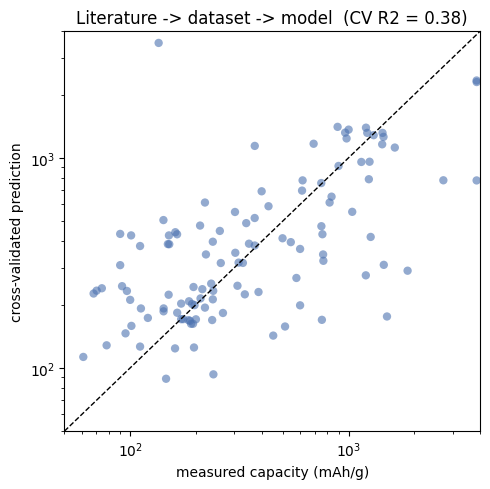

top drivers: ['chemistry_family_Li-S', 'cycle_number', 'chemistry_family_Li-metal', 'electrode_role_anode', 'current_density_A_g', 'C_rate']


In [8]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

d = data[data["specific_capacity_mAh_g"].notna()].copy()
d = d[d["specific_capacity_mAh_g"].between(1, 4000)]          # physical bound; drops rare parse outliers
y = np.log10(d["specific_capacity_mAh_g"].astype(float))     # capacity spans ~60-3600 mAh/g, so model log10
feat = d[["chemistry_family","electrode_role","current_density_A_g","C_rate","cycle_number","voltage_V"]]
X = pd.get_dummies(feat, columns=["chemistry_family","electrode_role"], dummy_na=True)
X = X.apply(pd.to_numeric, errors="coerce"); X = X.fillna(X.median(numeric_only=True)).fillna(0.0)

model = VotingRegressor([("rf", RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1)),
                         ("xgb", XGBRegressor(n_estimators=400, learning_rate=0.05, max_depth=4,
                                              subsample=0.8, random_state=0))])
# small table -> use 5-fold out-of-fold predictions for an honest score and a full parity plot
oof = cross_val_predict(model, X, y, cv=KFold(5, shuffle=True, random_state=0))
r2  = r2_score(y, oof)
print(f"predict specific capacity (log10 mAh/g) from the extracted descriptors, n={len(d)}")
print(f"  5-fold cross-validated R2 = {r2:.3f}")
print("  chemistry family carries most of the signal: Li-S / Li-metal high, intercalation lower")

fig, ax = plt.subplots(figsize=(5,5))
ax.scatter(10**y, 10**oof, alpha=.6, color="#4C72B0", edgecolor="none")
lim=[50, 4000]; ax.plot(lim, lim, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim,
       xlabel="measured capacity (mAh/g)", ylabel="cross-validated prediction",
       title=f"Literature -> dataset -> model  (CV R2 = {r2:.2f})")
os.makedirs("figures", exist_ok=True); fig.tight_layout(); fig.savefig("figures/2c_capacity_parity.png", dpi=140); plt.show()

imp = RandomForestRegressor(n_estimators=400, random_state=0, n_jobs=-1).fit(X, y).feature_importances_
print("top drivers:", list(pd.Series(imp, index=X.columns).nlargest(6).index))

## What you built

A closed loop, all from a topic: **OQL search -> open-access corpus -> full text -> an LLM-extracted table -> a model of specific capacity.** Change the OQL to your own field and the whole pipeline follows. The pre-crawled cache lets it run offline in seconds; live mode does it for real with a DeepSeek key.